<a href="https://colab.research.google.com/github/Capaquira/projectsLivreLow-code/blob/Notebooks/CombinedCyclePowerPlant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    explained_variance_score
)

In [2]:
Source = pd.read_csv('https://oreil.ly/zY85-?raw=true',on_bad_lines = 'skip',engine='python')
Source.head()

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
Source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9590 entries, 0 to 9589
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temp               9588 non-null   float64
 1   Exhaust_Vacuum     9588 non-null   float64
 2   Ambient_Pressure   9590 non-null   float64
 3   Relative_Humidity  9589 non-null   float64
 4   Energy_Production  9588 non-null   float64
dtypes: float64(5)
memory usage: 374.7 KB


In [4]:
Source

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9585,16.65,49.69,1014.01,91.00,-1.00
9586,13.19,39.18,1023.67,66.78,469.62
9587,31.32,74.33,1012.92,36.48,429.57
9588,24.48,69.45,1013.86,62.39,435.74


In [5]:
Source.describe()

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
count,9588.000000,9588.000000,9590.000000,9589.000000,9588.000000
mean,19.650898,54.312708,1012.732335,73.310847,454.223516
std,7.451627,12.710058,23.880984,14.603013,18.870459
min,1.810000,25.360000,0.000000,25.560000,-1.000000
25%,13.510000,41.740000,1009.100000,63.330000,439.740000
50%,20.350000,52.080000,1012.940000,74.970000,451.505000
75%,25.720000,66.540000,1017.257500,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [6]:
Source.isnull().sum()

,0
Temp,2
Exhaust_Vacuum,2
Ambient_Pressure,0
Relative_Humidity,1
Energy_Production,2


In [7]:
Source = Source.dropna()

In [8]:
Source.isnull().sum()

,0
Temp,0
Exhaust_Vacuum,0
Ambient_Pressure,0
Relative_Humidity,0
Energy_Production,0


In [11]:
Source.describe().round(2)

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
count,9584.00,9584.00,9584.00,9584.00,9584.00
mean,19.65,54.31,1012.73,73.31,454.23
std,7.45,12.71,23.89,14.60,18.87
min,1.81,25.36,0.00,25.56,-1.00
25%,13.51,41.74,1009.10,63.33,439.74
50%,20.34,52.08,1012.94,74.97,451.50
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


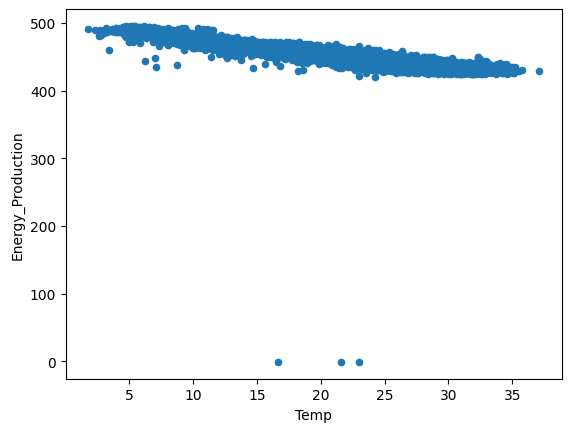

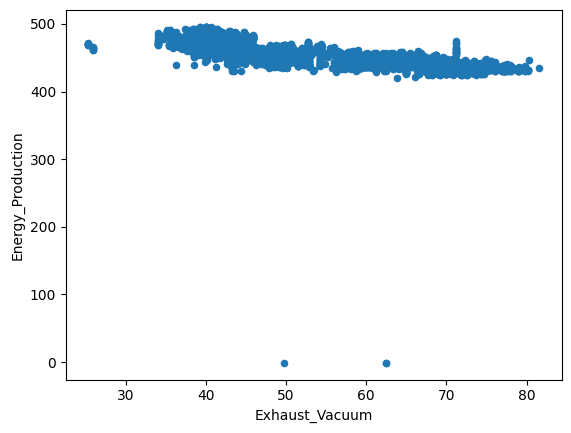

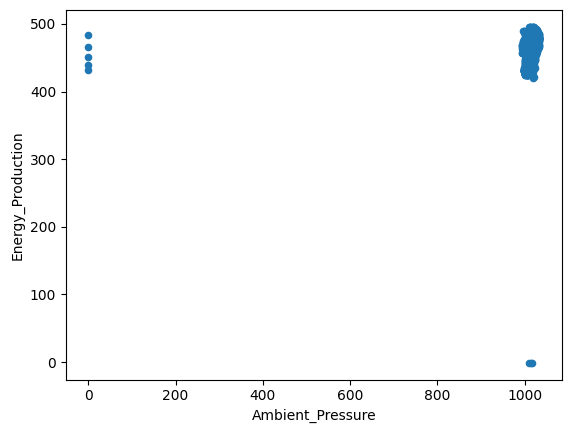

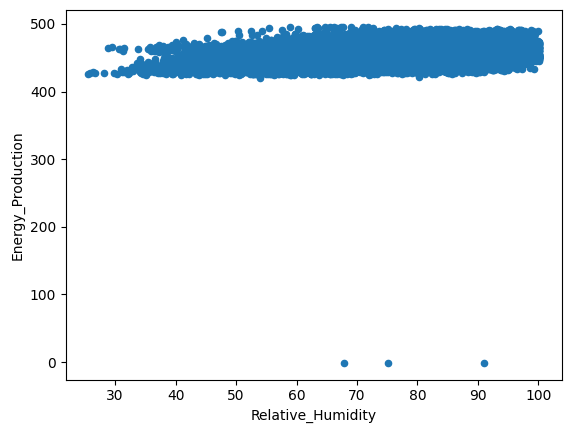

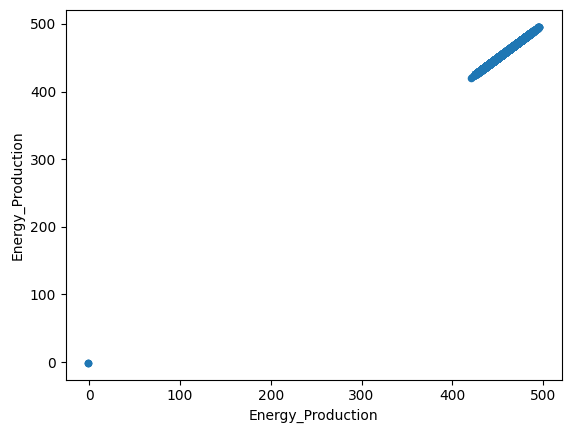

In [17]:
for col in Source.columns:
    Source.plot.scatter(x=col, y='Energy_Production')
    plt.show()

**Normal Operating** **Conditions**

In [16]:
Source.describe().round(2)

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
count,9584.00,9584.00,9584.00,9584.00,9584.00
mean,19.65,54.31,1012.73,73.31,454.23
std,7.45,12.71,23.89,14.60,18.87
min,1.81,25.36,0.00,25.56,-1.00
25%,13.51,41.74,1009.10,63.33,439.74
50%,20.34,52.08,1012.94,74.97,451.50
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


For this take into account the table with **the min and max ** but also the areas of importances **from the chart**

---



In [27]:

limits = {
    'Temp': (1.81, 37.11),
    'Exhaust_Vacuum': (25.36, 81.56),
    'Ambient_Pressure': (800, 1033.30),
    'Relative_Humidity': (25.56, 100.16),
    'Energy_Production': (350, 550)
}

mask = pd.Series(True, index=Source.index)

for col, (min_val, max_val) in limits.items():
  mask &= Source[col].between(min_val, max_val)

Source_Filtrado = Source[mask]

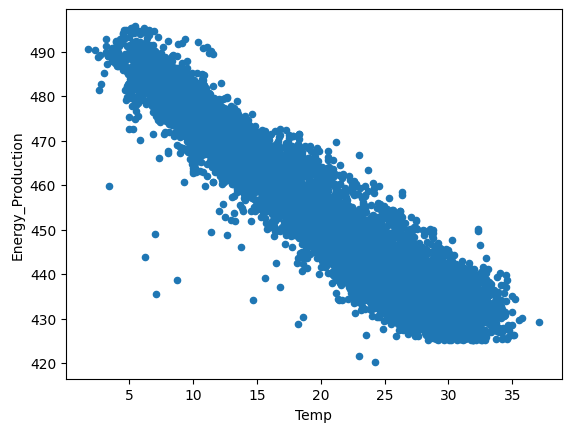

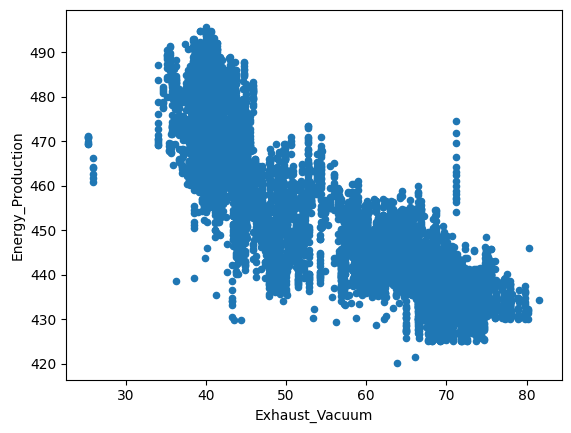

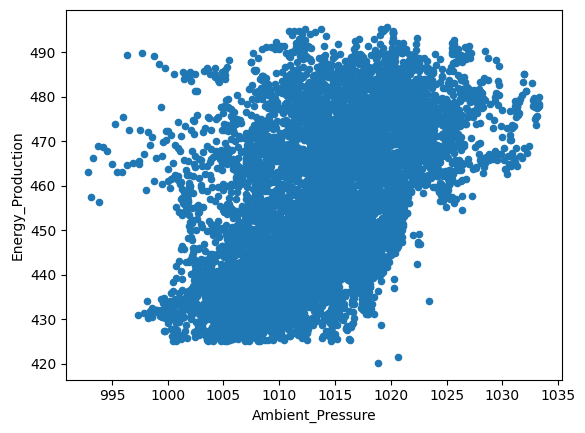

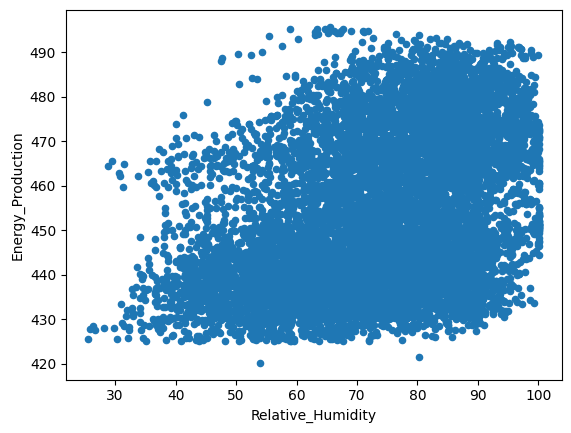

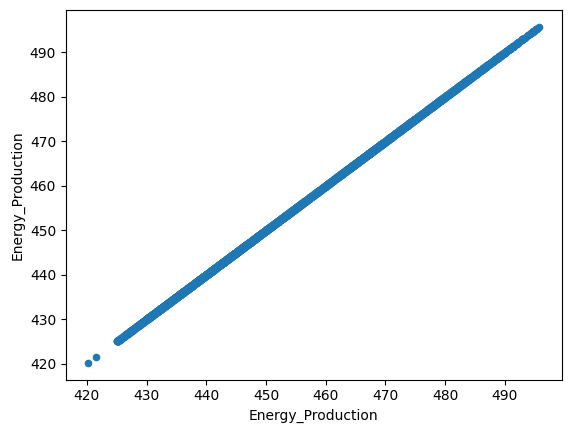

In [28]:
for col in Source_Filtrado.columns:
    Source_Filtrado.plot.scatter(x=col, y='Energy_Production')
    plt.show()

**Correlation Factor**

In [29]:
Source_Filtrado.corr().round(2)

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
Temp,1.00,0.84,-0.51,-0.54,-0.95
Exhaust_Vacuum,0.84,1.00,-0.41,-0.31,-0.87
Ambient_Pressure,-0.51,-0.41,1.00,0.10,0.52
Relative_Humidity,-0.54,-0.31,0.10,1.00,0.39
Energy_Production,-0.95,-0.87,0.52,0.39,1.00


<Axes: >

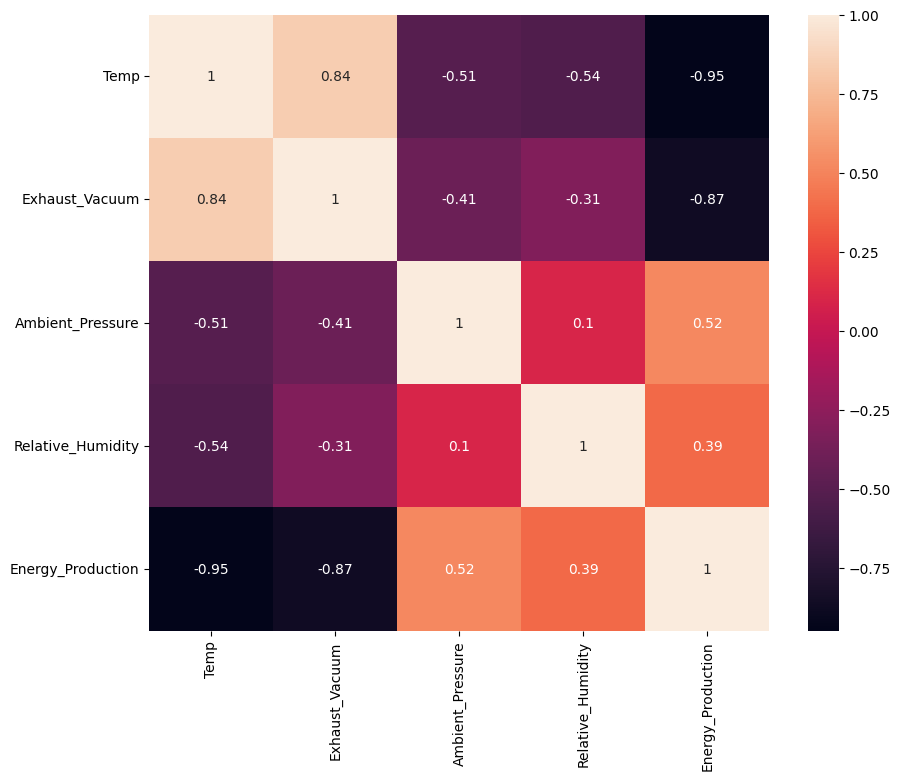

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(Source_Filtrado.corr(), annot=True)

<Axes: >

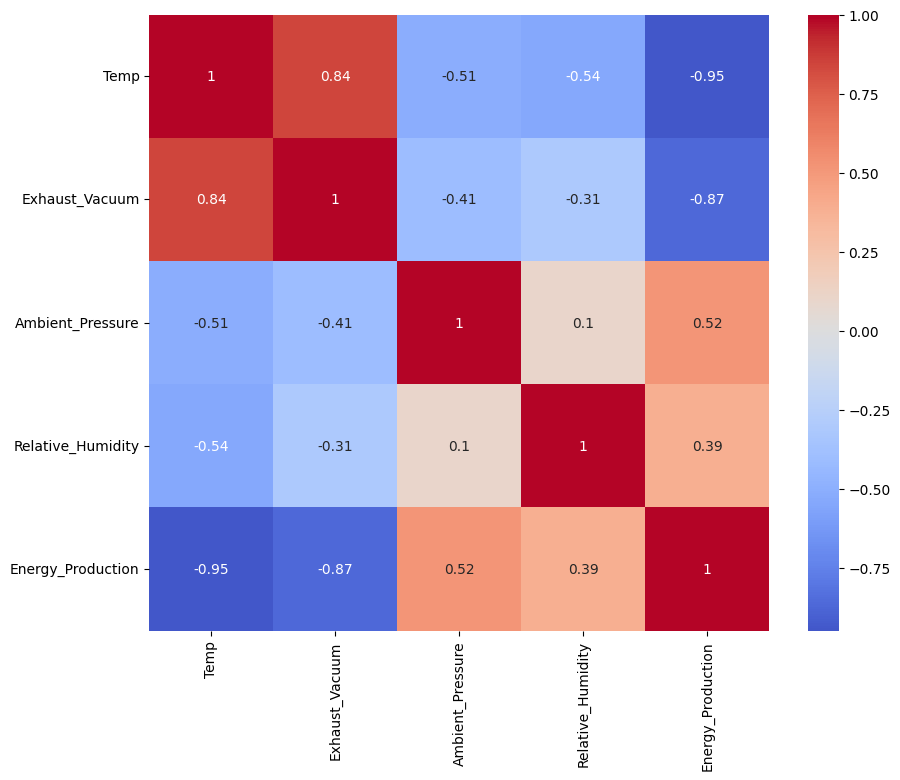

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(Source_Filtrado.corr(), annot=True,cmap="coolwarm",center=0)

**Linear model**

In [38]:

# Separar variables
X = Source_Filtrado.drop(columns=['Energy_Production'])
y = Source_Filtrado['Energy_Production']

# Dividir datos (80% train, mezclados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    shuffle=True,
    random_state=42
)

# Crear modelo
model = LinearRegression()

# Entrenar
model.fit(X_train, y_train)

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Función para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    msle = mean_squared_log_error(y_true, np.maximum(0, y_pred))
    r2 = r2_score(y_true, y_pred)
    ev = explained_variance_score(y_true, y_pred)

    return [mae, mse, rmse, msle, r2, ev]

# Crear tabla
metricas = pd.DataFrame(
    [calcular_metricas(y_train, y_train_pred),
     calcular_metricas(y_test, y_test_pred)],
    columns=["MAE", "MSE", "RMSE", "MSLE", "R2", "Explained Variance"],
    index=["Train", "Test"]
)

In [41]:
metricas.round(2)

,MAE,MSE,RMSE,MSLE,R2,Explained Variance
Train,3.62,20.59,4.54,0.0,0.93,0.93
Test,3.65,21.53,4.64,0.0,0.93,0.93


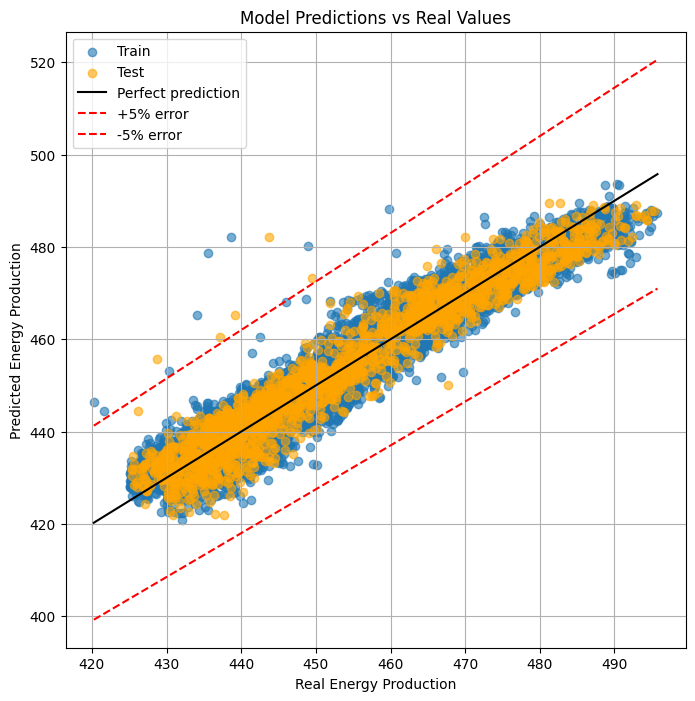

In [42]:
plt.figure(figsize=(8,8))

# scatter
plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test", color="orange")

# línea perfecta
min_val = min(y_test.min(), y_train.min())
max_val = max(y_test.max(), y_train.max())

x = np.linspace(min_val, max_val, 100)

plt.plot(x, x, color="black", label="Perfect prediction")

# banda ±5%
plt.plot(x, x*1.05, linestyle="--", color="red", label="+5% error")
plt.plot(x, x*0.95, linestyle="--", color="red", label="-5% error")

plt.xlabel("Real Energy Production")
plt.ylabel("Predicted Energy Production")
plt.title("Model Predictions vs Real Values")

plt.legend()
plt.grid(True)
plt.show()